In [1]:
# Cell 0: Setup — install dependencies and print versions
!pip -q install pandas numpy statsmodels openpyxl xlsxwriter matplotlib

import pandas as pd, numpy as np, statsmodels, sys, matplotlib
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("statsmodels:", statsmodels.__version__)
print("matplotlib:", matplotlib.__version__)
print("python:", sys.version)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.1 MB/s eta 0:00:00
pandas: 2.2.2
numpy: 2.0.2
statsmodels: 0.14.5
matplotlib: 3.10.0
python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [2]:
# Cell 1: Imports, helpers, and nice plotting utilities
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

# ---- Pretty plotting defaults (poster/paper friendly) ----
plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 300,
    "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12
})

# ---- Text helpers ----
def has_any(text, terms):
    t = str(text)
    return int(any(term in t for term in terms))

def zh_len(s):
    return len(str(s))

def count_pat(s, pat):
    return len(re.findall(pat, str(s)))

# ---- Tidy regression output for selected terms ----
def tidy(res, keys, model_label):
    return pd.DataFrame({
        "model": model_label,
        "term": keys,
        "coef": [res.params.get(k, np.nan) for k in keys],
        "se_cluster_year": [res.bse.get(k, np.nan) for k in keys],
        "p_value": [res.pvalues.get(k, np.nan) for k in keys]
    })

def star(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# ---- Forest plot of key coefficients (+95% CI) ----
def forest_plot(df_coef, title, xlab="Coefficient", fname="forest_did_ddd.png"):
    """
    Draw a simple forest plot: one dot per coefficient with 95% CI.
    df_coef columns: ['model','term','coef','se_cluster_year']
    """
    df = df_coef.copy()
    if df.empty:
        print("No coefficients to plot.")
        return
    df["lo"] = df["coef"] - 1.96*df["se_cluster_year"]
    df["hi"] = df["coef"] + 1.96*df["se_cluster_year"]
    df["label"] = df["model"] + " • " + df["term"]
    df = df.sort_values(["model","term"], ascending=[True, True])
    y = np.arange(len(df))[::-1]

    fig, ax = plt.subplots(figsize=(8, 0.45*len(df) + 1.5))
    ax.axvline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.errorbar(df["coef"], y, xerr=1.96*df["se_cluster_year"],
                fmt="o", capsize=3, elinewidth=1.2, linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df["label"])
    ax.set_xlabel(xlab)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight")
    plt.show()

# ---- Event study (year-by-year, ref=1936) ----
def event_study_year(df, ref_year=1936, fname="event_study_year.png"):
    """
    Build Female×Year interactions (excluding ref_year), estimate LPM with FE and
    cluster-by-year SEs, and plot coefficients relative to ref_year.
    Returns (coef_table, statsmodels_result).
    """
    d = df.copy()
    years = sorted(d["year"].unique())
    for y in years:
        if y == ref_year:
            continue
        d[f"F_x_year_{y}"] = d["female_mention"] * (d["year"] == y).astype(int)

    base = "title_len + n_qmark + n_exclam + has_digit + has_quote + C(year) + C(month)"
    int_terms = [c for c in d.columns if c.startswith("F_x_year_")]
    formula = "y_pol ~ female_mention + " + " + ".join(int_terms) + " + " + base

    res = smf.ols(formula=formula, data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["year"]}
    )

    rows = []
    for y in years:
        if y == ref_year:
            continue
        name = f"F_x_year_{y}"
        if name in res.params.index:
            rows.append({"year": y,
                         "coef": res.params[name],
                         "se":   res.bse[name],
                         "p":    res.pvalues[name]})
    est = pd.DataFrame(rows).sort_values("year")

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    # Shade war window (1937–45) and peak (1939–41)
    ax.axvspan(1937, 1945, alpha=0.08, label="War window (1937–45)")
    ax.axvspan(1939, 1941, alpha=0.12, label="Peak (1939–41)")
    # Points + 95% CI
    ax.errorbar(est["year"], est["coef"], yerr=1.96*est["se"],
                fmt="o-", capsize=3, elinewidth=1.2, linewidth=1.0)
    # Shock marker
    ax.axvline(1937, linestyle="-.", linewidth=1, alpha=0.7, label="1937 (shock)")
    ax.set_title(f"Event Study: Female × Year (ref = {ref_year})\nOutcome: Polarity index; SE clustered by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Coefficient relative to ref")
    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    seen, h2, l2 = set(), [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            h2.append(h); l2.append(l); seen.add(l)
    ax.legend(h2, l2, frameon=False, loc="best")
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight")
    plt.show()

    # Wald joint test: all pre-years = 0
    pre_names = [f"F_x_year_{y}" for y in years if y < ref_year and f"F_x_year_{y}" in res.params.index]
    if pre_names:
        idx = [res.params.index.get_loc(n) for n in pre_names]
        R = np.zeros((len(pre_names), len(res.params)))
        for i, j in enumerate(idx): R[i, j] = 1.0
        wtest = res.wald_test(R)
        print("Joint test (all pre-years coeffs = 0):")
        print("  F-stat:", float(getattr(wtest, "fvalue", wtest.statistic)))
        print("  p-value:", float(wtest.pvalue))

    return est, res

# ---- Event-time study (leads/lags, capped; ref bin k = -1 i.e., 1936) ----
def event_time_study(df, origin=1937, k_min=-10, k_max=8, fname="event_study_eventtime.png"):
    """
    Build Female × 1{k=k0} (k = year-origin, capped), drop k=-1 (1936) as ref bin,
    estimate LPM with FE and cluster-by-year SEs, and plot coefficients by event time.
    Returns (coef_table, statsmodels_result).
    """
    d = df.copy()
    d["k"] = d["year"] - origin
    d["k_cap"] = d["k"].clip(lower=k_min, upper=k_max)

    for k in range(k_min, k_max+1):
        if k == -1:  # ref bin (year=1936)
            continue
        d[f"F_x_k_{k}"] = d["female_mention"] * (d["k_cap"] == k).astype(int)

    base = "title_len + n_qmark + n_exclam + has_digit + has_quote + C(year) + C(month)"
    int_terms = [c for c in d.columns if c.startswith("F_x_k_")]
    formula = "y_pol ~ female_mention + " + " + ".join(int_terms) + " + " + base

    res = smf.ols(formula=formula, data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["year"]}
    )

    rows = []
    for k in range(k_min, k_max+1):
        if k == -1:
            continue
        name = f"F_x_k_{k}"
        if name in res.params.index:
            rows.append({"event_time_k": k,
                         "coef": res.params[name],
                         "se":   res.bse[name],
                         "p":    res.pvalues[name]})
    est = pd.DataFrame(rows).sort_values("event_time_k")

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    # Shade post (k>=0) and peak (k=2..4 ≈ 1939–41)
    ax.axvspan(0, est["event_time_k"].max(), alpha=0.08, label="Post")
    ax.axvspan(2, 4, alpha=0.12, label="Peak (≈1939–41)")
    ax.errorbar(est["event_time_k"], est["coef"], yerr=1.96*est["se"],
                fmt="o-", capsize=3, elinewidth=1.2, linewidth=1.0)
    ax.set_title("Event-time Study: Female × k (ref bin k = -1 i.e., 1936)\nOutcome: Polarity index; SE clustered by year")
    ax.set_xlabel("Event time k (years relative to 1937)")
    ax.set_ylabel("Coefficient relative to ref bin")
    ax.legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    return est, res


In [3]:
# Cell 2: Load data (choose one method)

# 2A) Manual upload (easiest)
from google.colab import files
uploaded = files.upload()  # select final_sentiment_sentprop.xlsx
df = pd.read_excel("final_sentiment_sentprop.xlsx", sheet_name="Sheet1")
display(df.head())

# # 2B) From Google Drive (optional)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_excel("/content/drive/MyDrive/final_sentiment_sentprop.xlsx", sheet_name="Sheet1")
# display(df.head())



Saving final_sentiment_sentprop.xlsx to final_sentiment_sentprop.xlsx


,_dataset,_group,_title,_time,year,year_infer,title_has_ta,lex_hits,sentprop_score,sp_label_3way,sp_label_2way
0,1911-1937,G1_pre,野史氏辨狱丛谈,1911-01-11,1911,1911,0,1,0.791328,positive,positive
1,1911-1937,G1_pre,政党组织之必要,1911-01-17,1911,1911,0,3,0.720829,positive,positive
2,1911-1937,G1_pre,论大隈伯对待淸国谈之谬妄（续昨）,1911-01-20,1911,1911,0,1,0.268679,negative,negative
3,1911-1937,G1_pre,学部注最小学教育,1911-02-02,1911,1911,0,3,0.644851,positive,positive
4,1911-1937,G1_pre,幸未成灾,1911-02-06,1911,1911,0,1,0.079015,negative,negative


In [4]:
# Cell 3: Feature engineering for DID/DDD and event studies

# Window
df = df[(df["year"] >= 1911) & (df["year"] <= 1949)].copy()

# Types
df["_title"] = df["_title"].astype(str)
df["_time"]  = pd.to_datetime(df["_time"])

# Labels (3-way guard)
df = df[df["sp_label_3way"].isin(["positive","neutral","negative"])].copy()

# Outcomes
df["y_pos"] = (df["sp_label_3way"]=="positive").astype(int)
df["y_neg"] = (df["sp_label_3way"]=="negative").astype(int)
df["y_pol"] = df["y_pos"] - df["y_neg"]  # +1 / 0 / -1

# Treatment: female mention (include "她" and broader "女/妇/…")
female_terms = [
    "她","女","妇","女性","妇女","女人","女士","小姐","太太","姑娘",
    "妻","妻子","母","母亲","妇人","女工","女兵","女童","女学生","女教师",
    "女记者","女代表","妇救","妇联","妇协"
]
if "title_has_ta" not in df.columns:
    df["title_has_ta"] = 0
df["female_mention"] = df["title_has_ta"].astype(int) | df["_title"].apply(lambda s: has_any(s, female_terms))

# Post and segments
war_start = pd.Timestamp("1937-07-07")
df["post1937"]   = (df["_time"] >= war_start).astype(int)
df["early_war"]  = ((df["_time"] >= war_start) & (df["year"] <= 1941)).astype(int)
df["midlate_war"]= ((df["year"] >= 1942) & (df["year"] <= 1945)).astype(int)

# Simple text controls
df["title_len"] = df["_title"].apply(zh_len)
df["n_qmark"]   = df["_title"].apply(lambda s: count_pat(s, r"[？?]"))
df["n_exclam"]  = df["_title"].apply(lambda s: count_pat(s, r"[！!]"))
df["has_digit"] = df["_title"].apply(lambda s: 1 if re.search(r"\d", s) else 0)
df["has_quote"] = df["_title"].apply(lambda s: 1 if re.search(r"[“”\"']", s) else 0)
df["month"]     = df["_time"].dt.month

# War/production topic for DDD
war_terms = ['工','厂','劳','兵','军','救','动员','征','慰','前线','生产','征募','后方','战时','妇救','妇联']
df["war_topic"] = df["_title"].apply(lambda s: int(any(t in s for t in war_terms)))

# Control blocks with/without lex_hits
has_lex = "lex_hits" in df.columns
fe_block      = " + C(year) + C(month)"
surface_block = "title_len + n_qmark + n_exclam + has_digit + has_quote"
block_no_lex  = surface_block + fe_block
block_with_lex= surface_block + (" + lex_hits" if has_lex else "") + fe_block

print({
    "N_total": int(len(df)),
    "share_female": float(df["female_mention"].mean()),
    "share_post": float(df["post1937"].mean()),
    "has_lex_hits": has_lex
})



{'N_total': 89300, 'share_female': 0.11432250839865621, 'share_post': 0.7789137737961926, 'has_lex_hits': True}


In [5]:
# Cell 4: Model A — Baseline DID on polarity (clustered by year)

# (A1) No lex_hits (recommended for main text to avoid bad-control risk)
form_A1 = f"y_pol ~ female_mention + post1937 + female_mention:post1937 + {block_no_lex}"
A1 = smf.ols(formula=form_A1, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
print(A1.summary().tables[1])
tab_A1 = tidy(A1, ["female_mention","post1937","female_mention:post1937"], "A1: DID y_pol (no lex)")

# (A2) With lex_hits (if present)
if has_lex:
    form_A2 = f"y_pol ~ female_mention + post1937 + female_mention:post1937 + {block_with_lex}"
    A2 = smf.ols(formula=form_A2, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
    print(A2.summary().tables[1])
    tab_A2 = tidy(A2, ["female_mention","post1937","female_mention:post1937"], "A2: DID y_pol (with lex)")
else:
    tab_A2 = pd.DataFrame(columns=["model","term","coef","se_cluster_year","p_value"])

display(tab_A1)
if len(tab_A2): display(tab_A2)



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 56, but rank is 18
  warnings.warn('covariance of constraints does not have full '


                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.0865      0.042      2.040      0.041       0.003       0.170
C(year)[T.1912]             0.2768      0.021     12.923      0.000       0.235       0.319
C(year)[T.1913]             0.1630      0.018      9.023      0.000       0.128       0.198
C(year)[T.1914]             0.0803      0.016      4.994      0.000       0.049       0.112
C(year)[T.1916]             0.7883      0.017     46.328      0.000       0.755       0.822
C(year)[T.1917]             0.1039      0.019      5.596      0.000       0.068       0.140
C(year)[T.1918]            -0.1759      0.012    -15.038      0.000      -0.199      -0.153
C(year)[T.1919]            -0.0962      0.018     -5.208      0.000      -0.132      -0.060
C(year)[T.1920]             0.0740      0.017      4.299      0.000       0.040 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 57, but rank is 19
  warnings.warn('covariance of constraints does not have full '


,model,term,coef,se_cluster_year,p_value
0,A1: DID y_pol (no lex),female_mention,0.377325,0.071520,1.321714e-07
1,A1: DID y_pol (no lex),post1937,0.049394,0.019106,9.728694e-03
2,A1: DID y_pol (no lex),female_mention:post1937,-0.033010,0.078886,6.756150e-01


,model,term,coef,se_cluster_year,p_value
0,A2: DID y_pol (with lex),female_mention,0.358663,0.068315,1.520134e-07
1,A2: DID y_pol (with lex),post1937,0.037596,0.018714,4.454231e-02
2,A2: DID y_pol (with lex),female_mention:post1937,-0.030067,0.075611,6.908814e-01


In [6]:
# Cell 5: Model B — Segmented DID (early vs mid/late war)

# (B1) No lex_hits
form_B1 = f"""y_pol ~ female_mention + early_war + midlate_war
               + female_mention:early_war + female_mention:midlate_war
               + {block_no_lex}"""
B1 = smf.ols(formula=form_B1, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
print(B1.summary().tables[1])
tab_B1 = tidy(B1, ["female_mention:early_war","female_mention:midlate_war","female_mention","early_war","midlate_war"],
              "B1: Segmented DID y_pol (no lex)")

# (B2) With lex_hits
if has_lex:
    form_B2 = f"""y_pol ~ female_mention + early_war + midlate_war
                   + female_mention:early_war + female_mention:midlate_war
                   + {block_with_lex}"""
    B2 = smf.ols(formula=form_B2, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
    print(B2.summary().tables[1])
    tab_B2 = tidy(B2, ["female_mention:early_war","female_mention:midlate_war","female_mention","early_war","midlate_war"],
                  "B2: Segmented DID y_pol (with lex)")
else:
    tab_B2 = pd.DataFrame(columns=["model","term","coef","se_cluster_year","p_value"])

display(tab_B1)
if len(tab_B2): display(tab_B2)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 58, but rank is 19
  warnings.warn('covariance of constraints does not have full '


                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.0893      0.043      2.092      0.036       0.006       0.173
C(year)[T.1912]                0.2742      0.022     12.581      0.000       0.231       0.317
C(year)[T.1913]                0.1604      0.018      8.709      0.000       0.124       0.197
C(year)[T.1914]                0.0780      0.016      4.871      0.000       0.047       0.109
C(year)[T.1916]                0.7855      0.016     48.025      0.000       0.753       0.818
C(year)[T.1917]                0.1011      0.019      5.342      0.000       0.064       0.138
C(year)[T.1918]               -0.1783      0.012    -15.404      0.000      -0.201      -0.156
C(year)[T.1919]               -0.0970      0.019     -5.210      0.000      -0.134      -0.061
C(year)[T.1920]                0.0743      0.017  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 20
  warnings.warn('covariance of constraints does not have full '


,model,term,coef,se_cluster_year,p_value
0,B1: Segmented DID y_pol (no lex),female_mention:early_war,0.186105,0.054495,6.375734e-04
1,B1: Segmented DID y_pol (no lex),female_mention:midlate_war,-0.015433,0.057446,7.881967e-01
2,B1: Segmented DID y_pol (no lex),female_mention,0.321855,0.035666,1.810997e-19
3,B1: Segmented DID y_pol (no lex),early_war,0.022826,0.013358,8.747561e-02
4,B1: Segmented DID y_pol (no lex),midlate_war,-0.012365,0.015975,4.389332e-01


,model,term,coef,se_cluster_year,p_value
0,B2: Segmented DID y_pol (with lex),female_mention:early_war,0.183525,0.049857,2.322746e-04
1,B2: Segmented DID y_pol (with lex),female_mention:midlate_war,-0.006959,0.057976,9.044638e-01
2,B2: Segmented DID y_pol (with lex),female_mention,0.304855,0.032722,1.203602e-20
3,B2: Segmented DID y_pol (with lex),early_war,0.011736,0.013160,3.725219e-01
4,B2: Segmented DID y_pol (with lex),midlate_war,-0.125959,0.016026,3.850034e-15


In [8]:
# Cell 6: Model D — Triple-difference (DDD) in war/production topics
# Uses: df, block_no_lex, block_with_lex, has_lex (from earlier cells)

# (D1) No lex_hits
form_D1 = "y_pol ~ female_mention*post1937*war_topic + " + block_no_lex
D1 = smf.ols(formula=form_D1, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
print(D1.summary().tables[1])
tab_D1 = tidy(D1, ["female_mention:post1937:war_topic",
                   "female_mention:post1937","female_mention:war_topic","post1937:war_topic",
                   "female_mention","post1937","war_topic"],
              "D1: DDD y_pol (no lex)")

# (D2) With lex_hits
if has_lex:
    form_D2 = "y_pol ~ female_mention*post1937*war_topic + " + block_with_lex
    D2 = smf.ols(formula=form_D2, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["year"]})
    print(D2.summary().tables[1])
    tab_D2 = tidy(D2, ["female_mention:post1937:war_topic",
                       "female_mention:post1937","female_mention:war_topic","post1937:war_topic",
                       "female_mention","post1937","war_topic"],
                  "D2: DDD y_pol (with lex)")
else:
    tab_D2 = pd.DataFrame(columns=["model","term","coef","se_cluster_year","p_value"])

display(tab_D1)
if len(tab_D2): display(tab_D2)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 22
  warnings.warn('covariance of constraints does not have full '


                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0688      0.035      1.957      0.050      -0.000       0.138
C(year)[T.1912]                       0.2782      0.017     16.827      0.000       0.246       0.311
C(year)[T.1913]                       0.1779      0.016     11.416      0.000       0.147       0.208
C(year)[T.1914]                       0.0886      0.014      6.434      0.000       0.062       0.116
C(year)[T.1916]                       0.8028      0.017     46.798      0.000       0.769       0.836
C(year)[T.1917]                       0.0840      0.019      4.430      0.000       0.047       0.121
C(year)[T.1918]                      -0.1684      0.010    -16.428      0.000      -0.188      -0.148
C(year)[T.1919]                      -0.0930      0.014     -6.626      0.000     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 61, but rank is 23
  warnings.warn('covariance of constraints does not have full '


,model,term,coef,se_cluster_year,p_value
0,D1: DDD y_pol (no lex),female_mention:post1937:war_topic,0.241217,0.155988,1.220126e-01
1,D1: DDD y_pol (no lex),female_mention:post1937,-0.063838,0.082426,4.386425e-01
2,D1: DDD y_pol (no lex),female_mention:war_topic,-0.007908,0.141638,9.554753e-01
3,D1: DDD y_pol (no lex),post1937:war_topic,-0.230764,0.100023,2.104924e-02
4,D1: DDD y_pol (no lex),female_mention,0.378391,0.073415,2.547798e-07
5,D1: DDD y_pol (no lex),post1937,0.058824,0.021041,5.178099e-03
6,D1: DDD y_pol (no lex),war_topic,0.166619,0.083196,4.520552e-02


,model,term,coef,se_cluster_year,p_value
0,D2: DDD y_pol (with lex),female_mention:post1937:war_topic,0.206806,0.149354,1.661528e-01
1,D2: DDD y_pol (with lex),female_mention:post1937,-0.058224,0.079045,4.613687e-01
2,D2: DDD y_pol (with lex),female_mention:war_topic,0.015770,0.133311,9.058312e-01
3,D2: DDD y_pol (with lex),post1937:war_topic,-0.239091,0.097515,1.421269e-02
4,D2: DDD y_pol (with lex),female_mention,0.358162,0.069958,3.060848e-07
5,D2: DDD y_pol (with lex),post1937,0.048733,0.020463,1.724299e-02
6,D2: DDD y_pol (with lex),war_topic,0.143592,0.081115,7.668932e-02


In [16]:
# Cell P0: Define production/mobilization topic and war-seed hits (as a control)

import re

# 1) Production/Mobilization lexicon (feel free to tweak)
prod_terms = [
    "工","厂","生产","动员","征募","募捐","慰劳","后方","支援","劳工","纺织",
    "军工","弹药","粮","运输","卫生","护士","救护","宣传","募款","配给",
    "缝纫","志愿","妇救","妇联","妇协","动员令","模范","表彰","服务队","志愿队"
]
def has_any_term(s, terms):
    t = str(s)
    return int(any(w in t for w in terms))

if "topic_prod" not in df.columns:
    df["topic_prod"] = df["_title"].apply(lambda s: has_any_term(s, prod_terms))

# 2) War-seed (NEGATIVE) lexicon you used for sentiment seeding
# Replace/extend this list with YOUR actual negative seeds if available.
war_seed_neg = [
    "战斗","前线","轰炸","空袭","伤亡","阵亡","撤退","侵略","炮火","警报","危机",
    "饥荒","困难","艰苦","牺牲","戒严","封锁","配给","征用","弹尽","告急","灾难"
]

def count_terms(s, terms):
    t = str(s)
    return sum(t.count(w) for w in terms)

# Raw count and length-adjusted intensity (per 20 chars)
df["war_seed_hits"] = df["_title"].apply(lambda s: count_terms(s, war_seed_neg)).astype(int)
df["title_len"] = df["title_len"] if "title_len" in df.columns else df["_title"].apply(len)
df["war_seed_intensity"] = df["war_seed_hits"] / (df["title_len"].replace(0,1) / 20.0)

# Build adjusted control block: add war_seed_intensity to your surface controls
surface_block = "title_len + n_qmark + n_exclam + has_digit + has_quote"
fe_block = " + C(year) + C(month)"
block_no_lex_waradj = surface_block + " + war_seed_intensity" + fe_block

print({
    "share_topic_prod": float(df["topic_prod"].mean()),
    "mean_war_seed_hits": float(df["war_seed_hits"].mean())
})



{'share_topic_prod': 0.04742441209406495, 'mean_war_seed_hits': 0.010918253079507279}


In [22]:
# Cell E0: Build yearly mobilization intensity (share of mobilization titles)
# Uses your title text column `_title`. If you've already defined prod lexicon, reuse/merge.

import pandas as pd
import numpy as np
import re

# 1) A mobilization/production lexicon (feel free to tweak)
mobil_terms = [
    "动员","组织","宣传","募捐","表彰","模范","妇救","妇联","妇协","服务队","志愿队",
    "女工","工厂","车间","纺织","缝纫","军工","弹药","生产","运输","粮","配给","征用",
    "护士","救护","卫生","慰劳","后方","支援","志愿","募款"
]

def has_any_term(s, terms):
    t = str(s);
    return int(any(w in t for w in terms))

if "mobil_flag" not in df.columns:
    df["mobil_flag"] = df["_title"].apply(lambda s: has_any_term(s, mobil_terms))

# 2) Yearly intensity = share of mobilization titles in year (0~1)
mob_year = (df.groupby("year", as_index=False)
              .agg(mobil_share=("mobil_flag","mean"),
                   n_year=("mobil_flag","size")))
df = df.merge(mob_year, on="year", how="left")

# 3) Optional: standardize intensity to mean 0, sd 1 (helps interpret)
df["mobil_z"] = (df["mobil_share"] - df["mobil_share"].mean()) / df["mobil_share"].std()

print(df[["year","mobil_share","mobil_z"]].drop_duplicates().sort_values("year").tail(15).head())


       year  mobil_share   mobil_z
11962  1935     0.004076 -1.376922
14906  1936     0.005479 -1.298607
18009  1937     0.007380 -1.192428
20177  1938     0.029459  0.040476
23877  1939     0.019748 -0.501819


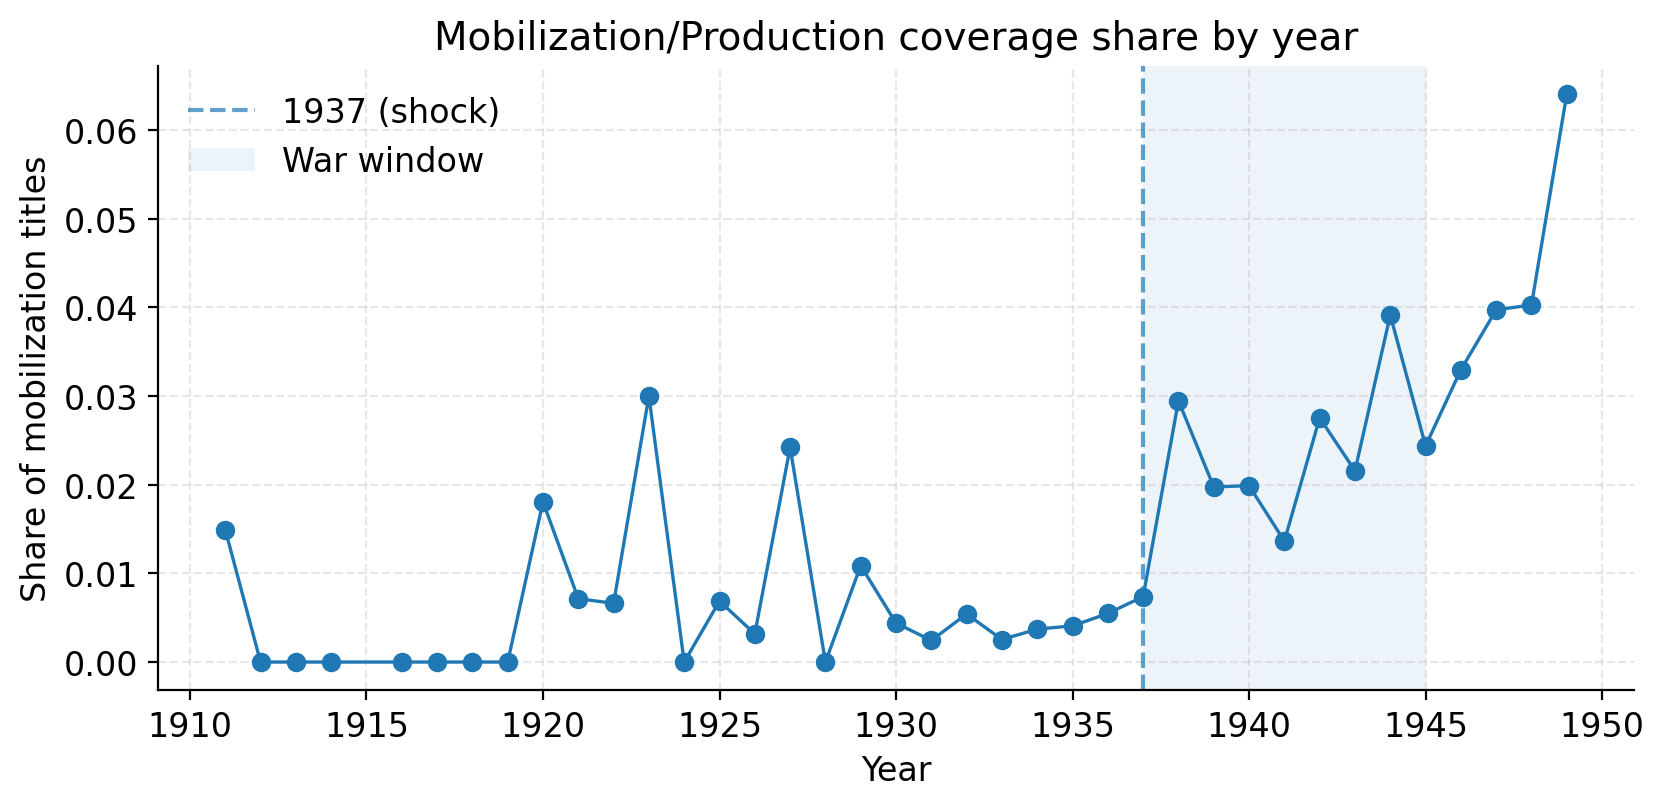

In [23]:
# Cell E1: Plot mobilization share by year to check it rises after 1937
import matplotlib.pyplot as plt

ys = (df[["year","mobil_share"]].drop_duplicates()
        .sort_values("year"))
plt.figure(figsize=(8.5,4.2))
plt.plot(ys["year"], ys["mobil_share"], marker="o", lw=1.2)
plt.axvline(1937, ls="--", alpha=0.7, label="1937 (shock)")
plt.axvspan(1937, 1945, alpha=0.08, label="War window")
plt.title("Mobilization/Production coverage share by year")
plt.xlabel("Year"); plt.ylabel("Share of mobilization titles")
plt.legend(frameon=False); plt.tight_layout(); plt.show()


In [24]:
# Cell E2: Dose-DDD — Female × Post × MobilizationIntensity
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Controls (war_seed_intensity was defined earlier; if not, drop it from the block)
surface = "title_len + n_qmark + n_exclam + has_digit + has_quote"
maybe_warseed = " + war_seed_intensity" if "war_seed_intensity" in df.columns else ""
fe = " + C(year) + C(month)"
block = surface + maybe_warseed + fe

# Full saturated triple with all lower-order terms
form_E2 = f"""y_pol ~ female_mention*mobil_z*post1937 + {block}"""

E2 = smf.ols(formula=form_E2, data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["year"]})
print(E2.summary().tables[1])

# Tidy key terms
def tidy(res, keep, model_name):
    rows=[]
    for k in keep:
        if k in res.params.index:
            rows.append({"model": model_name, "term": k,
                         "coef": float(res.params[k]),
                         "se_cluster_year": float(res.bse[k]),
                         "p_value": float(res.pvalues[k])})
    return pd.DataFrame(rows)

tab_E2 = tidy(E2, [
    "female_mention:post1937:mobil_z",
    "female_mention:post1937",
    "female_mention:mobil_z",
    "post1937:mobil_z"
], "E2: Dose-DDD")
display(tab_E2)


                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.0560      0.055      1.012      0.312      -0.053       0.165
C(year)[T.1912]                     0.2444      0.010     24.581      0.000       0.225       0.264
C(year)[T.1913]                     0.1305      0.008     15.506      0.000       0.114       0.147
C(year)[T.1914]                     0.0480      0.010      4.605      0.000       0.028       0.068
C(year)[T.1916]                     0.7552      0.016     48.053      0.000       0.724       0.786
C(year)[T.1917]                     0.0732      0.011      6.937      0.000       0.052       0.094
C(year)[T.1918]                    -0.2086      0.009    -23.649      0.000      -0.226      -0.191
C(year)[T.1919]                    -0.1288      0.006    -21.116      0.000      -0.141      -0.117


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 61, but rank is 21
  warnings.warn('covariance of constraints does not have full '


,model,term,coef,se_cluster_year,p_value
0,E2: Dose-DDD,female_mention:post1937,0.032187,0.195132,0.868982
1,E2: Dose-DDD,female_mention:mobil_z,-0.037420,0.178433,0.833891


In [25]:
# Cell E3: Segmented dose-DDD — early vs mid/late war
form_E3 = f"""
y_pol ~ female_mention*mobil_z*early_war
      + female_mention*mobil_z*midlate_war
      + {block}
"""
E3 = smf.ols(formula=form_E3, data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["year"]})
print(E3.summary().tables[1])

tab_E3 = tidy(E3, [
    "female_mention:mobil_z:early_war",
    "female_mention:mobil_z:midlate_war"
], "E3: Segmented dose-DDD")
display(tab_E3)


                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.0809      0.045      1.794      0.073      -0.008       0.169
C(year)[T.1912]                        0.2694      0.018     14.623      0.000       0.233       0.305
C(year)[T.1913]                        0.1556      0.015     10.282      0.000       0.126       0.185
C(year)[T.1914]                        0.0728      0.014      5.293      0.000       0.046       0.100
C(year)[T.1916]                        0.7798      0.016     49.210      0.000       0.749       0.811
C(year)[T.1917]                        0.0979      0.016      6.137      0.000       0.067       0.129
C(year)[T.1918]                       -0.1837      0.009    -19.405      0.000      -0.202      -0.165
C(year)[T.1919]                       -0.1028      0.016     -6.597      

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 65, but rank is 23
  warnings.warn('covariance of constraints does not have full '


,model,term,coef,se_cluster_year,p_value
0,E3: Segmented dose-DDD,female_mention:mobil_z:early_war,0.103162,0.13101,0.431024
1,E3: Segmented dose-DDD,female_mention:mobil_z:midlate_war,0.217130,0.04601,0.000002


In [31]:
# Cell G0: Small helpers — clustered OLS + pretty forest plot (matplotlib only)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def fit_cluster(formula, data, cluster_col="year"):
    return smf.ols(formula=formula, data=data).fit(
        cov_type="cluster", cov_kwds={"groups": data[cluster_col]}
    )

def tidy(res, terms, model_name):
    rows=[]
    for t in terms:
        if t in res.params.index:
            rows.append({
                "model": model_name,
                "term": t,
                "coef": float(res.params[t]),
                "se": float(res.bse[t]),
                "p": float(res.pvalues[t]),
            })
    return pd.DataFrame(rows)

def forest_plot(df_coefs, title, xlab, fname=None):
    d = df_coefs.copy()
    d["lo"] = d["coef"] - 1.96*d["se"]
    d["hi"] = d["coef"] + 1.96*d["se"]
    y = np.arange(len(d))[::-1]

    plt.figure(figsize=(8.4, 4.8))
    plt.axvline(0, ls="--", lw=1, color="gray", alpha=0.7)
    plt.errorbar(d["coef"], y, xerr=1.96*d["se"], fmt="o", capsize=3, lw=1.2)
    plt.yticks(y, d["model"])
    plt.xlabel(xlab); plt.title(title)
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


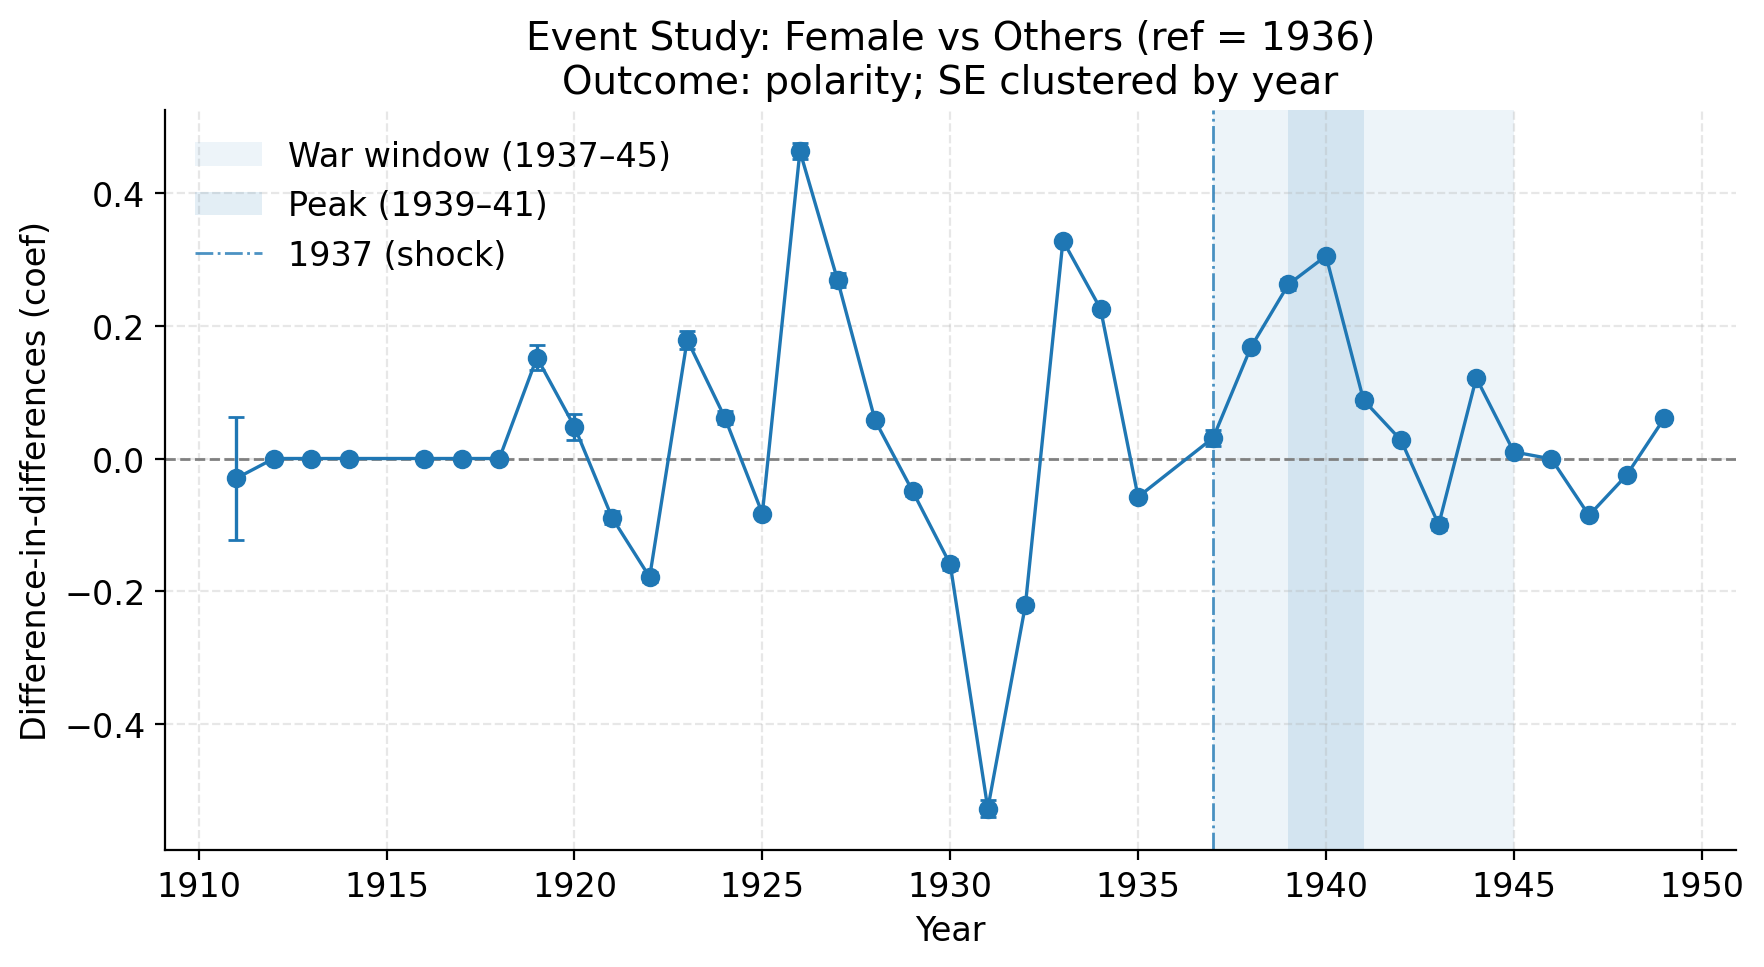

,year,coef,se
0,1911,-2.979797e-02,4.717693e-02
1,1912,-7.265714e-16,2.662196e-17
2,1913,-1.321321e-15,4.745602e-17
3,1914,1.631202e-16,3.108265e-17
4,1916,5.711388e-16,2.786985e-17


In [32]:
# Cell G1: Event study (parallel trends) for Female vs Others, ref = 1936
# Interprets each year's female-vs-others difference relative to 1936.
# If you already have a similar function, feel free to skip this cell.

# Fallbacks for controls
if "title_len" not in df.columns: df["title_len"] = df["_title"].apply(len)
surface = "title_len + n_qmark + n_exclam + has_digit + has_quote"
maybe_warseed = " + war_seed_intensity" if "war_seed_intensity" in df.columns else ""
fe = " + C(year) + C(month)"
controls = surface + maybe_warseed + fe

ref_year = 1936
es_formula = (
    f"y_pol ~ female_mention + {controls} "
    f"+ female_mention:C(year, Treatment(reference={ref_year}))"
)

es_res = fit_cluster(es_formula, df)
# Collect interaction terms
rows=[]
for nm in es_res.params.index:
    if nm.startswith("female_mention:C(year"):
        y = int(nm.split("T.")[1][:-1])
        rows.append({"year": y, "coef": es_res.params[nm], "se": es_res.bse[nm]})
es_tbl = pd.DataFrame(rows).sort_values("year")

# Pretty plot
plt.figure(figsize=(9,5))
plt.axhline(0, ls="--", lw=1, color="gray")
plt.axvspan(1937, 1945, alpha=0.08, label="War window (1937–45)")
plt.axvspan(1939, 1941, alpha=0.12, label="Peak (1939–41)")
plt.errorbar(es_tbl["year"], es_tbl["coef"], yerr=1.96*es_tbl["se"],
             fmt="o-", capsize=3, lw=1.2)
plt.axvline(1937, ls="-.", lw=1, alpha=0.8, label="1937 (shock)")
plt.title("Event Study: Female vs Others (ref = 1936)\nOutcome: polarity; SE clustered by year")
plt.xlabel("Year"); plt.ylabel("Difference-in-differences (coef)")
plt.legend(frameon=False, loc="best")
plt.tight_layout(); plt.savefig("ES_female_vs_others.png", dpi=300, bbox_inches="tight")
plt.show()

es_tbl.head()


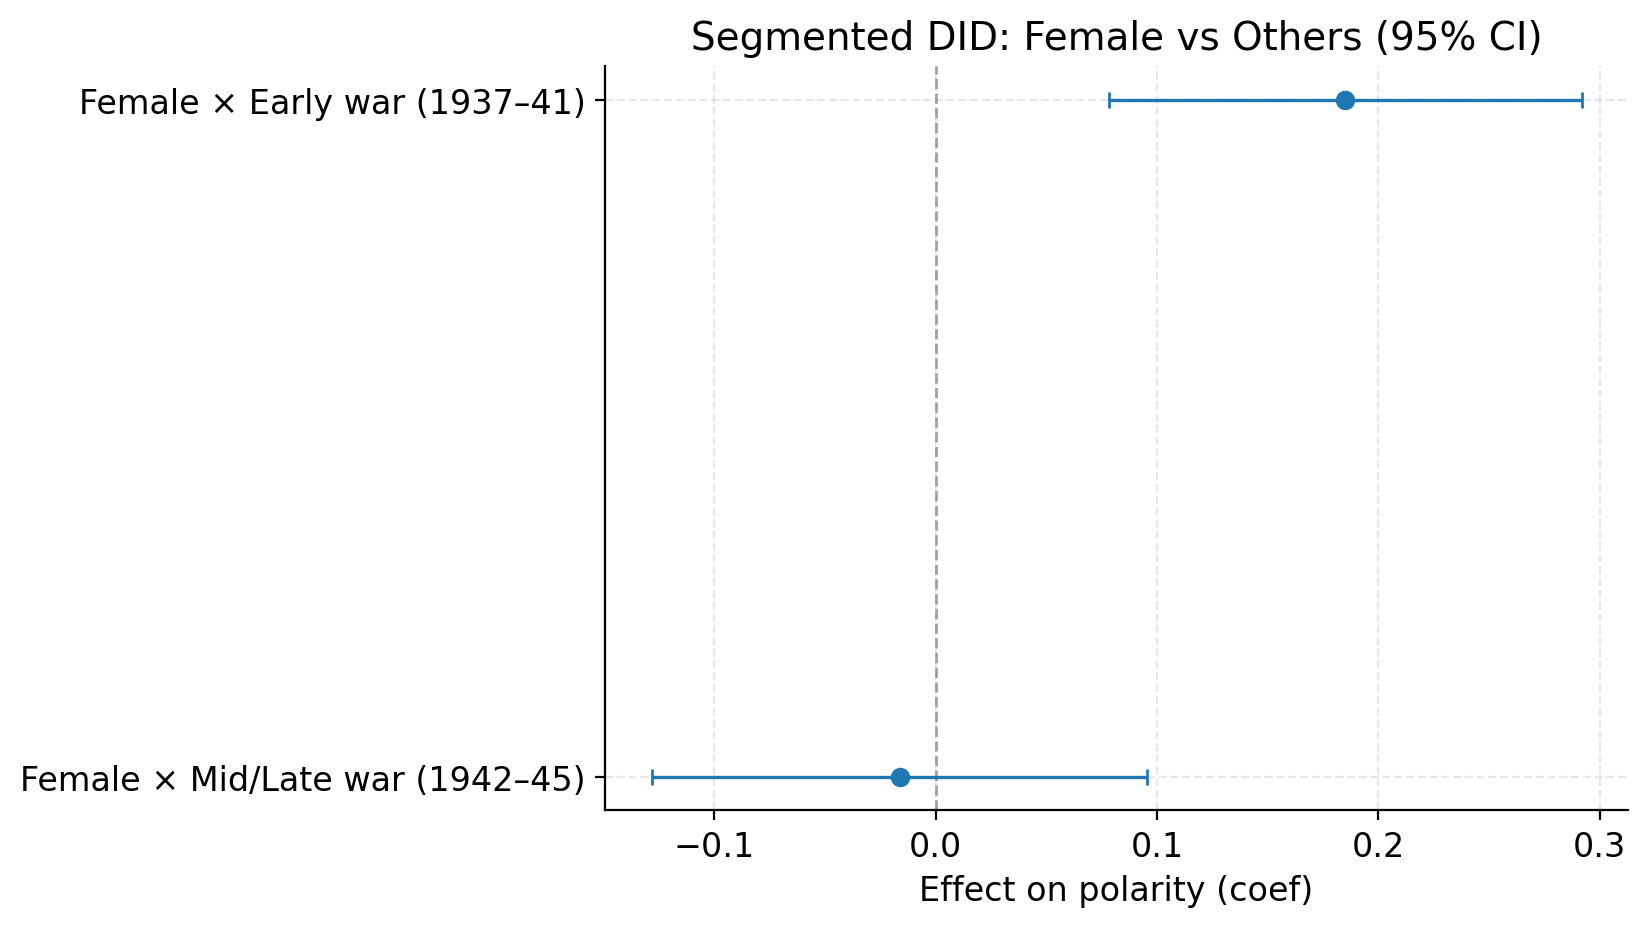

,model,term,coef,se,p
0,Segmented DID (Female vs Others),female_mention:early_war,0.185010,0.054517,0.000690
1,Segmented DID (Female vs Others),female_mention:midlate_war,-0.016314,0.057162,0.775331


In [33]:
# Cell G2: Forest plot for segmented DID (Female × Early/Midlate)
# Matches your A/B main results; clean one-glance figure for poster.

seg_formula = """
y_pol ~ female_mention + early_war + midlate_war
      + female_mention:early_war + female_mention:midlate_war
      + """ + controls

seg_res = fit_cluster(seg_formula, df)
tab_seg = tidy(
    seg_res,
    ["female_mention:early_war", "female_mention:midlate_war"],
    "Segmented DID (Female vs Others)"
)
forest_plot(
    tab_seg.assign(model=["Female × Early war (1937–41)",
                          "Female × Mid/Late war (1942–45)"]),
    title="Segmented DID: Female vs Others (95% CI)",
    xlab="Effect on polarity (coef)",
    fname="forest_segmented_DID.png"
)
tab_seg


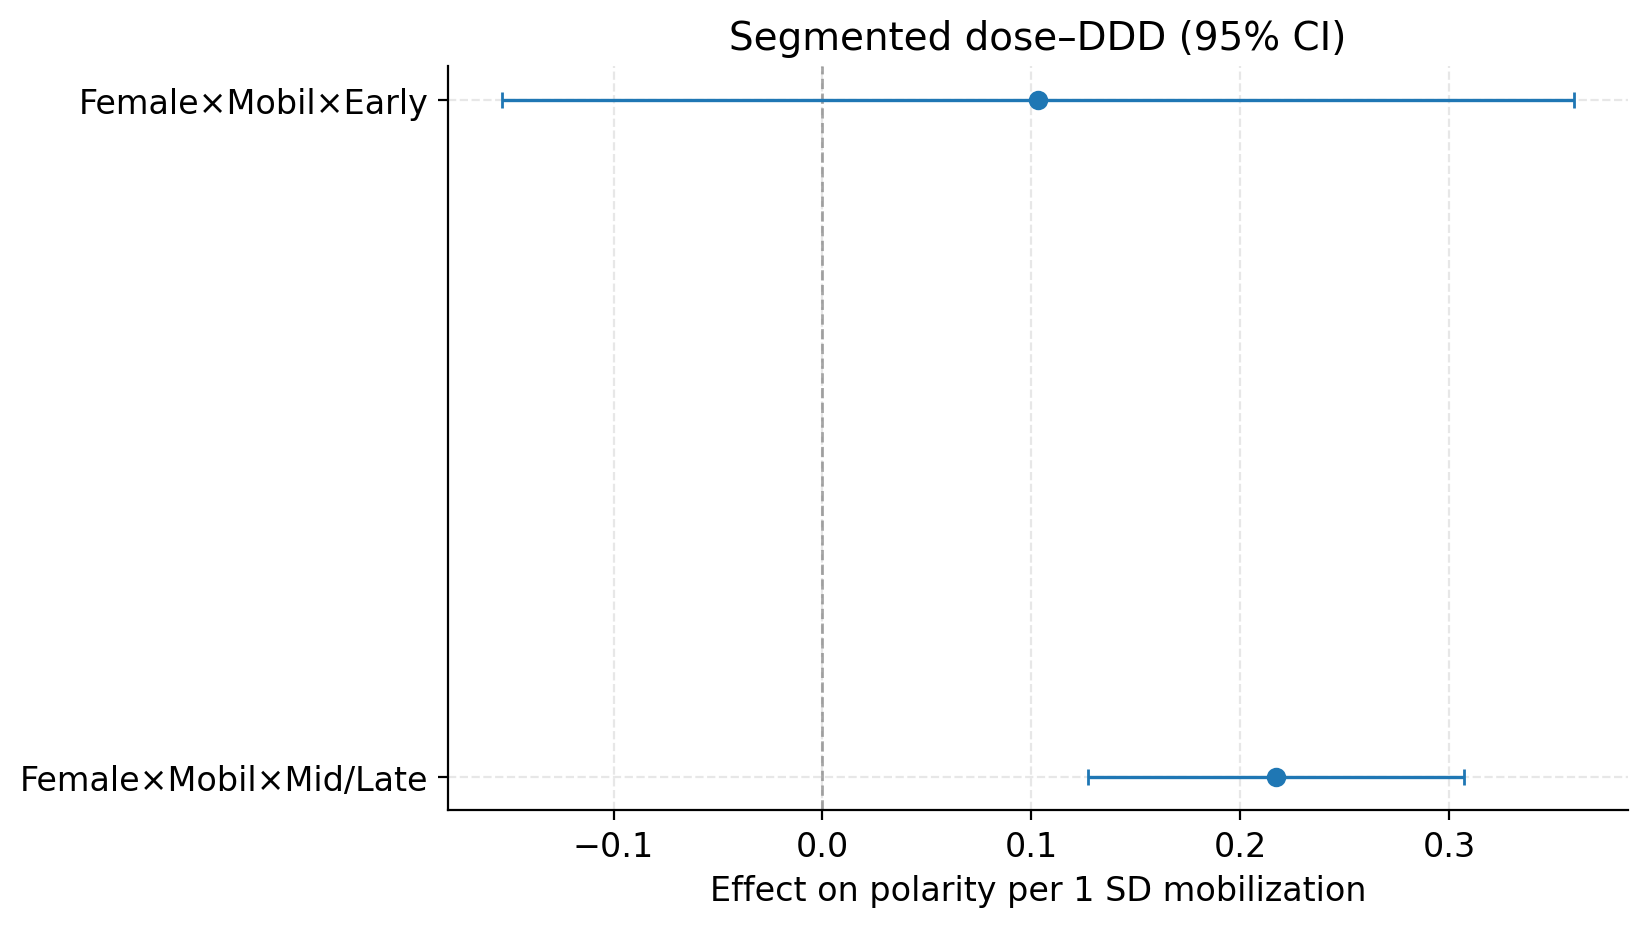

,model,term,coef,se,p
0,Segmented dose–DDD,female_mention:mobil_z:early_war,0.103162,0.13101,0.431024
1,Segmented dose–DDD,female_mention:mobil_z:midlate_war,0.217130,0.04601,0.000002


In [34]:
# Cell G3: Forest plot for segmented dose-DDD (Female × Mobilization × Period)

# Ensure mobil_z exists (from your E0 step); otherwise build a quick share-by-year
if "mobil_z" not in df.columns:
    mobil_terms = ["动员","组织","宣传","募捐","表彰","模范","妇救","妇联","妇协","服务队","志愿队",
                   "女工","工厂","纺织","缝纫","军工","弹药","生产","运输","粮","配给","征用",
                   "护士","救护","卫生","慰劳","后方","支援","志愿","募款"]
    def has_any_term(s, terms):
        t=str(s); return int(any(w in t for w in terms))
    df["mobil_flag"] = df["_title"].apply(lambda s: has_any_term(s, mobil_terms))
    share = df.groupby("year", as_index=False).agg(mobil_share=("mobil_flag","mean"))
    df = df.merge(share, on="year", how="left")
    df["mobil_z"] = (df["mobil_share"] - df["mobil_share"].mean())/df["mobil_share"].std()

dose_seg = """
y_pol ~ female_mention*mobil_z*early_war
      + female_mention*mobil_z*midlate_war
      + """ + controls

E3 = fit_cluster(dose_seg, df)
tab_dose = tidy(
    E3,
    ["female_mention:mobil_z:early_war", "female_mention:mobil_z:midlate_war"],
    "Segmented dose–DDD"
)
forest_plot(
    tab_dose.assign(model=["Female×Mobil×Early", "Female×Mobil×Mid/Late"]),
    title="Segmented dose–DDD (95% CI)",
    xlab="Effect on polarity per 1 SD mobilization",
    fname="forest_dose_DDD.png"
)
tab_dose
